In [1]:
# import packages, declare constants, get the parent directory
import pandas as pd
import numpy as np
import re
import os
import time
import decimal
from scipy import stats
#from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib import colormaps
#from .utils import helpers
#import simplemma
import pyvoikko

CHATGPT_RELEASE_YEAR = int(2022)
FINNISH_ALPHABET = 'abcdefghijklmnopqrstuvwxyzåäö'

def get_parent_directory() -> str:
    """Get the parent directory for handling csv files.

    Returns:
        string: the path to the directory where directories for csv files are located
    """
    #create relative path for parent
    relative_parent = os.path.join(os.getcwd(), '..')

    #use abspath for absolute parent path
    return str(os.path.abspath(relative_parent)).replace('\\', '/')

directory = get_parent_directory()

DECLARE FUNCTIONS

In [ ]:
def clean_string(string: str) -> str:
    try:
        # remove blanks in start and end
        string = string.strip()
        string = string.lower()
        # the string must contain characters
        if any(c in string for c in FINNISH_ALPHABET)==False:
            string = ''
        # remove tabulations, line breaks etc., also special characters
        remove_these = r'[\+\*!"”’?.:,…()§\'[\] \t\n\r\f\v]'
        string = re.sub(remove_these, '', string)
        # remove weird parentheses and backwards linebreaks from starts of strings
        string = re.sub(r'^\)\\[a-z]', '', string)
        # remove weird '\[alphabet]' strings at start of strings
        string = re.sub(r'^\\[a-z]', '', string)
        # remove numbers
        string = re.sub(r'[0-9]', '', string)
        # remove dashes '-' at the start and end of string
        string = re.sub(r'^-|-$', '', string)
        # remove individual forward and backward slashes '/', '\'
        string = re.sub(r'[\/\\]', '', string)
        # remove double dashes '--'
        string = string.replace('--', '-')
        # remove the equal sign '='
        string = string.replace('=', '')
        # at the end of the cleaning, remove all characters from the string which are not in the alphabet except for dash (compound words)
        remove_these = ''.join([str(c) for c in string if c != '-' and c not in [i for i in FINNISH_ALPHABET]])
        string = re.sub(remove_these, '', string)
        # remove blanks in start and end again
        string = string.strip()
        # remove empty if string length < 2
        string = '' if len(string) < 2 else string
        return string
    except:
        print(f'Unexpected error at helpers.clean_string(), string: {string}')
        raise

In [3]:
def count_word_freqs_in_string(string: str):
    """Counts the words in the input string.
    Returns a dictionary where the word is the key and the frequency is the value.
    """
    if ((string is None) or (string == 'nan')):
        return None
    else:
        words_list = re.split(' ', string)
        wordfreq_dict = {}
        for word in words_list:
            if word not in wordfreq_dict.keys():
                wordfreq_dict[word] = 1
            else:
                wordfreq_dict[word] += 1

        return wordfreq_dict

In [4]:
def get_normalised(df: pd.DataFrame, speaker_id: str, year: int, word_n: int) -> float:
    w_min = df['word_n'].loc[(df['speaker_id']==speaker_id)&(df['year']==year)].min()
    w_max = df['word_n'].loc[(df['speaker_id']==speaker_id)&(df['year']==year)].max()
    return ((word_n-w_min)/(w_max-w_min))

In [5]:
def linear_extrapolation(y: list, x: list, n=1) -> list:
    """Linear extrapolation based on last two x and y observations. Returns the extrapolated value of y for a given x based on y1x1 and y2x2.
    Parameter x will be standardised to a running sequence of numbers so extrapolations works on a linear scale.
    Args:
        y (list): list of values
        x (list): list of values
        n (int, optional): for how many times shall extrapolation be done. Defaults to 1. Larger values will start extrapolating on extrapolated values.

    Returns:
        list: extrapolated value(s) of y. The length of the list will be n.
    """
    # x and y must be arrays of same length
    # CHANGE THIS TO ASSERT
    if len(y) != len(x):
        print('array length mismatch')
        return None
    else:
        # format helper parameters to not modify lists outside the function
        xx = [*[i for i in x]]
        yy = [*[i for i in y]]
        return_list = [] # format list to be returned
        # loop n times -> return list of n length with n extrapolations
        # note: extrapolating on extrapolations if n>1
        while n >= 1:
            # format xx: it shall take a running sequence of numbers as its values
            xx = [i for i in range(len(x))]
            m = (yy[-1] - yy[-2]) / (xx[-1] - xx[-2])
            y_v = yy[-2] + m * ((xx[-1] + 1) - xx[-2])
            xx.append([xx[-1]+1])
            yy.append(y_v)
            return_list.append(y_v)
            n = n-1
        return return_list

In [ ]:
# create the data in loops: 
## > loop the csvs for years 2015-2025
## > extract each word per speaker per df (=year), this is done in a for loop
## > combine them all into dataframe df_speaker_words_year
# declare the years
year, max_year = 2015, 2025
# start looping the csvs
while year <= max_year:
    # name for saving the file
    save_file_name = f'speaker_words_{year}.csv'
    if save_file_name in os.listdir(f'{directory}/csv_analysis/'):
        pass
    else:
        # get the csv to match the year from directory: directory/csv_lemmatized/
        year_csv = pd.read_csv(f'{directory}/csv_lemmatized/speeches_{year}.csv', sep=';', header=0)
        # format a dataframe to store the results
        # > columns: speaker_id, year, word, word_n (how many times the word appears)
        df_speaker_words_year = pd.DataFrame(columns=['speaker_id', 'year', 'word', 'word_n']).astype({'speaker_id': str, 'year': int, 'word': str, 'word_n': int})    
        # extract each word per speaker per df (=year)
        for speaker in year_csv['speaker_id'].loc[(year_csv['speaker_id'].notna()==True)&(year_csv['speaker_id'].str.len()>0)].unique():
            # extract only rows for the speaker in iteration, and only if a lemmatized speech exists, and only if the lemmatized speech is longer than 0 chars
            df_filtered = year_csv.loc[(year_csv['speaker_id']==speaker)&(year_csv['content_lemmatized'].notna()==True)&(year_csv['content_lemmatized'].str.len()>0)]
            # extract each lemmatized speech; compile them into a single string
            speaker_all_speeches = ' '.join(df_filtered['content_lemmatized'])
            # string cleaning: clean special characters from the string
            speaker_all_speeches = ' '.join([clean_string(word) for word in speaker_all_speeches.split(' ')])
            # get the count of each word in the string, return a dict
            speaker_words_dict = count_word_freqs_in_string(speaker_all_speeches)
            # delete empty '' keys (words) from the dict, if such have made it there. these are failed lemmatizations
            try:
                del speaker_words_dict['']
            except KeyError:
                pass
            # add the speaker's subset (speaker_id, year, word, word_n) in the combination dataframe
            # > from the speaker_words_dict, and year, and speaker
            # > create another "temporary" dataframe for this, concatenate this to the df_speaker_words_year df
            concat_df = pd.DataFrame.from_dict(data=speaker_words_dict, orient='index', columns=['word_n'])
            concat_df['speaker_id'], concat_df['year'], concat_df['word'] = speaker, year, concat_df.index
            concat_df.reset_index(drop=True, inplace=True)
            concat_df = concat_df[['speaker_id','year','word','word_n']]  
            df_speaker_words_year = pd.concat([df_speaker_words_year, concat_df], axis=0, ignore_index=True)
        # store the data in a csv (savepoint!)
        # > directory and file name template: directory/csv_analysis/speaker_words_YYYY.csv
        df_speaker_words_year.to_csv(f'{directory}/csv_analysis/{save_file_name}', sep=';', header=True, index=False, encoding='utf-8')
        # time for the next year
    year = year+1

# data for words per speaker for years 2015-2025 has now been created
df_speaker_words_comp = pd.DataFrame(columns=['speaker_id', 'year', 'word', 'word_n', 'word_norm']).astype({'speaker_id':str, 'year':int, 'word':str, 'word_n':int, 'word_norm':float})
for f in [file for file in os.listdir(f'{directory}/csv_analysis/') if re.search(r'speaker_words_\d+\.csv', file)]:
    df = pd.read_csv(f'{directory}/csv_analysis/{f}', sep=';', header=0, encoding='utf-8', dtype={'speaker_id': str, 'year': int, 'word': str, 'word_n': int})
    # calculate the normalised frequency of word per speaker per year: min-max normalisation
    # store in column: word_norm
    # running this in one apply with subqueries into the dataframe causes setting with copy warnings and takes way too long due to relatively large row counts
    # > therefore let's do this step by step with fewer repetitive queries
    df['word_norm'] = None
    # loop through each speaker
    for speaker in df['speaker_id'].unique():
        # minimum and maximum word counts per speaker
        w_min, w_max = df['word_n'].loc[df['speaker_id']==speaker].min(), df['word_n'].loc[df['speaker_id']==speaker].max()
        # calculate the normalised frequency per each word of the speaker
        df.loc[df['speaker_id']==speaker, 'word_norm'] = df.apply(lambda x: (x['word_n']-w_min)/(w_max-w_min), axis=1)
    df_speaker_words_comp = pd.concat([df_speaker_words_comp, df], axis=0, ignore_index=True)

# save as csv
file_path_write = f'{directory}/csv_analysis/speaker_words_comp.csv'
try:
    df_speaker_words_comp.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')
except FileExistsError:
    os.remove(file_path_write)
    df_speaker_words_comp.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')

In [ ]:
# compute extrapolated value for each speaker's each word:
# -> what would the extrapolated of the word be in 2023, 2024, 2025 based on the frequency in last preceeding years
df_speaker_words_comp = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp.csv',sep=';',header=0,encoding='utf-8',dtype={'speaker_id': str, 'year': int, 'word': str, 'word_n': int, 'word_norm':float})
# keep only records where the speaker_id is a valid identifier (string of numbers)
df_speaker_words_comp = df_speaker_words_comp.loc[df_speaker_words_comp['speaker_id'].str.contains(pat=r'\d+')==True]

# compute extrapolated values of word frequencies only for this range of years
loop_years = [2023, 2024, 2025]
for year in loop_years:
    # name for a new column: extrapolated word frequency
    # > a new column will be created for each looped year
    col_word_norm_extrap = f'word_norm_extrap_{year}'
    #df_speaker_words_comp[col_word_norm_extrap] = None
    # merging the dataframe will speed this up instead of looping each row
    # > create a new df to quickly compute the linear extrapolation for word frequency: df_merge
    # > df_merge is created by joining df_speaker_words_comp for year, said df year-1 and year-2 on speaker_id and word
    # > INNER JOIN filters rows where there are no normalised frequencies in the previous years -> extrapolation for these words would fail
    # > LEFT JOIN keeps all recrods - this can be done to keep the records 
    # > finally the extrapolated normalised frequency is updated into df_speaker_words_comp in the update
    df_merge = df_speaker_words_comp[['speaker_id','year','word','word_norm']].loc[df_speaker_words_comp['year']==year].merge(
                   df_speaker_words_comp[['speaker_id','year','word','word_norm']].loc[df_speaker_words_comp['year']==year-1],
                   how='left', on=['speaker_id', 'word'], suffixes=(None,'_t_1'))
    df_merge = df_merge.merge(df_speaker_words_comp[['speaker_id','year','word','word_norm']].loc[df_speaker_words_comp['year']==year-2],
        how='left', on=['speaker_id', 'word'], suffixes=(None,'_t_2'))
    df_merge[col_word_norm_extrap] = df_merge.apply(lambda x: linear_extrapolation(y=[x['word_norm_t_2'], x['word_norm_t_1']],x=[year-2, year-1],n=1)[0], axis=1)
    df_speaker_words_comp = df_speaker_words_comp.merge(df_merge[['speaker_id','word','year',col_word_norm_extrap]], how='left', on=['speaker_id','word','year'])

# collapse word_norm_extrap_[2023, 2024, 2025] into a single column, word_norm_extrap, since year is already a column in the df
df_speaker_words_comp.loc[df_speaker_words_comp['year']==2023, 'word_norm_extrap'] = df_speaker_words_comp['word_norm_extrap_2023'] 
df_speaker_words_comp.loc[df_speaker_words_comp['year']==2024, 'word_norm_extrap'] = df_speaker_words_comp['word_norm_extrap_2024'] 
df_speaker_words_comp.loc[df_speaker_words_comp['year']==2025, 'word_norm_extrap'] = df_speaker_words_comp['word_norm_extrap_2025']
# keep only columns speaker_id, year, word, word_n, word_norm, word_norm_extrap
df_speaker_words_comp = df_speaker_words_comp[['speaker_id','year','word','word_n','word_norm','word_norm_extrap']]

# compute differences and ratios between actual normalised frequencies and the extrapolated values:
# > diffs: actual value minus extrapolated value
# > ratios: actual value divided by extrapolated value
# >> replace None/NaN extrapolated value with 1 to avoid divide by zero errors
df_speaker_words_comp['word_diffs'] = df_speaker_words_comp.apply(lambda x: x['word_norm'] - x['word_norm_extrap'], axis=1)
df_speaker_words_comp['word_ratios'] = df_speaker_words_comp.apply(lambda x: x['word_norm'] / (1 if (x['word_norm_extrap'] is None or x['word_norm_extrap']==np.float64(0)) else x['word_norm_extrap']), axis=1)

# add word_class column before saving to csv - this takes a while so better to save after this
df_speaker_words_comp['word_class'] = df_speaker_words_comp.apply(lambda x: pyvoikko.analyse(x['word'])[0].CLASS if len(pyvoikko.analyse(x['word'])) != 0 else None, axis=1)

# checkpoint save
# save as csv
file_path_write = f'{directory}/csv_analysis/speaker_words_comp.csv'
try:
    df_speaker_words_comp.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')
except FileExistsError:
    os.remove(file_path_write)
    df_speaker_words_comp.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')

In [ ]:
# check for cases where diffs and ratios are higher in 2024 and 2025 than normalised frequenccy in previous years
# -> compare df (filtered df) to df_comp (unfiltered, years 2015-2025)
# -> we are interested in differences in 2024 & 2025 that are larger than in all previous years
# --> this filters out topic-related words that surface for topical issues and probably go out of vogue very soon (spikes in certain years)
# ---> observe change over time, see if there actually is anything there
# --> hypothesis: we could be left with "filler words"
# - loop down from year 2025 to 2015, pick speakers and words exist in all years
df_filter = pd.DataFrame(columns=['speaker_id', 'year', 'word', 'word_n', 'word_norm', 'word_norm_extrap', 'word_diffs', 'word_ratios', 'word_class']).astype({'speaker_id':str,'year':int,'word':str,'word_n':int,'word_norm':float,'word_norm_extrap':float,'word_diffs':float,'word_ratios':float, 'word_class':str})
years = df_speaker_words_comp['year'].unique()

# df_merge WILL BE SAVED IN WIDE FORMAT!!!
df_merge = pd.DataFrame(columns=['speaker_id','word','word_n_2015','word_norm_2015','word_norm_extrap_2015','word_diffs_2015','word_ratios_2015']).astype({'speaker_id':str,'word':str,'word_n_2015':int,'word_norm_2015':float,'word_norm_extrap_2015':float,'word_diffs_2015':float,'word_ratios_2015':float})
# get the speaker's words that appear in all years (2015-2025)
for year in years:
   # format for the first year
   if year==2015:
      df_merge = df_speaker_words_comp[['speaker_id','word_class','word','word_n','word_norm','word_norm_extrap','word_diffs','word_ratios']].loc[df_speaker_words_comp['year']==year]
      df_merge.rename(columns={'speaker_id':'speaker_id','word_class':'word_class','word':'word','word_n':'word_n_2015','word_norm':'word_norm_2015','word_norm_extrap':'word_norm_extrap_2015','word_diffs':'word_diffs_2015','word_ratios':'word_ratios_2015'}, inplace=True)
   # pass for 2025, no need to run this   
   if year==2025:
      pass
   else:
      df_merge = df_merge.merge(df_speaker_words_comp.loc[df_speaker_words_comp['year']==year+1], on=['speaker_id','word','word_class'], how='left', suffixes=(f'_{year}',f'_{year+1}'))

# ADDING Z-SCORES FOR FURTHER COMPARSIONS
year, max_year = 2015, 2025
speakers = df_merge['speaker_id'].unique()
while year <= max_year:
    col_name = f'z_{year}'
    df_merge[col_name] = None
    tmp_ser = pd.Series(data=None, dtype=float)

    for speaker in speakers:
        ser = df_merge[f'word_norm_{year}'].loc[df_merge['speaker_id']==speaker]
        z_scores = pd.Series(stats.zscore(ser))
        tmp_ser = pd.concat([tmp_ser, z_scores], ignore_index=True)

    df_merge[col_name] = tmp_ser
    year=year+1

# df_merge WILL BE SAVED IN WIDE FORMAT!!!
df_merge.to_csv(f'{directory}/csv_analysis/speaker_words_comp_wide.csv', header=True, encoding='utf-8', sep=';', index=False)

In [ ]:
# doesn't seem to turn out much.
# TO DO: check if WORD COUNTS for these speakers have got longer after 2022/2023
# check if certain word_class values have gone up after 2022/2023
# if sentence lengths appear to have increased for some MPs -> focus on these folks

# calculate the lengths of the speakers' speeches per year
# -> length of speech = number of words in speech
def calculate_speech_length(speech: str) -> int:
    # start processing only if the input value actually is a string
    if type(speech) == str:
        # clean each word in string
        speech = [clean_string(i) for i in speech.split(' ')]
        # return length of list: number of words in speech
        # -> check that the length of the word is over 0; clean_string returns '' for removed characters, such as '!'
        return len([i for i in speech if len(i)>0])
    else:
        return None

# get the speeches, combine them in a df: df_speeches
csvs = [i for i in os.listdir(f'{directory}/csv_lemmatized') if (re.match(r'speeches_\d+\.csv', i) and ((int((re.search(r'\d+', i)[0])) > 2014)))]

df_speeches = pd.DataFrame()

for csv in csvs:
    path = f'{directory}/csv_lemmatized/{csv}'
    df = pd.read_csv(path, sep=';', header=0, encoding='utf-8')
    # add 'year' column to df, populate with the year of the csv
    year = int(re.search(r'\d+', csv)[0])
    df['year'] = year
    if len(df_speeches)==0:
        df_speeches = df
    else:
        df_speeches = pd.concat([df_speeches, df], axis=0, ignore_index=True)

df_speeches['n_words_in_speech'] = df_speeches.apply(lambda x: calculate_speech_length(x['content_lemmatized']), axis=1)

# save speech lengths in a separate df
df_speech_lengths = pd.DataFrame(columns=['speaker_id','year','len_min','len_max','len_mean','len_median','words_total']).astype({'speaker_id':str,'year':int,'len_min':float,'len_max':float,'len_mean':float,'len_median':float,'words_total':int})
for speaker in df_speeches['speaker_id'].unique():
    for year in df_speeches['year'].loc[~df_speeches['speech_type'].isin(['PuhemiesPuheenvuoro'])].unique():
        len_min = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].min()
        len_max = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].max()
        len_mean = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].mean()
        len_median = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].median()
        words_total = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].sum()
        df_speech_lengths = pd.concat([df_speech_lengths,pd.DataFrame.from_dict(data={'speaker_id':[speaker], 'year':[year], 'len_min':[len_min], 'len_max':[len_max],'len_mean':[len_mean],'len_median':[len_median],'words_total':[words_total]}, orient='columns')], axis=0, ignore_index=True)

df_speech_lengths = df_speech_lengths[df_speech_lengths['speaker_id'].notna()]

# checkpoint save
# save df_speech_lengths to csv
file_path_write = f'{directory}/csv_analysis/speaker_speech_lengths.csv'
try:
    df_speech_lengths.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')
except FileExistsError:
    os.remove(file_path_write)
    df_speech_lengths.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')

# checkpoint save
# save df_speech_lengths to csv
file_path_write = f'{directory}/csv_analysis/speeches_combined_plus_length.csv'
try:
    df_speeches.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')
except FileExistsError:
    os.remove(file_path_write)
    df_speeches.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')

In [ ]:
# SAME PROCESSING FOR UNLEMMATISED WORDS

# create the data in loops: 
## > loop the csvs for years 2015-2025
## > extract each word per speaker per df (=year), this is done in a for loop
## > combine them all into dataframe df_speaker_words_year
# declare the years
year, max_year = 2015, 2025
# start looping the csvs
while year <= max_year:
    # name for saving the file
    save_file_name = f'speaker_words_{year}_nonlemma.csv'
    if save_file_name in os.listdir(f'{directory}/csv_analysis/'):
        pass
    else:
        # get the csv to match the year from directory: directory/csv_lemmatized/
        year_csv = pd.read_csv(f'{directory}/csv_lemmatized/speeches_{year}.csv', sep=';', header=0)
        # format a dataframe to store the results
        # > columns: speaker_id, year, word, word_n (how many times the word appears)
        df_speaker_words_year = pd.DataFrame(columns=['speaker_id', 'year', 'word', 'word_n']).astype({'speaker_id': str, 'year': int, 'word': str, 'word_n': int})    
        # extract each word per speaker per df (=year)
        for speaker in year_csv['speaker_id'].loc[(year_csv['speaker_id'].notna()==True)&(year_csv['speaker_id'].str.len()>0)].unique():
            # extract only rows for the speaker in iteration, and only if a speech exists, and only if the speech is longer than 0 chars
            df_filtered = year_csv.loc[(year_csv['speaker_id']==speaker)&(year_csv['content'].notna()==True)&(year_csv['content'].str.len()>0)]
            # extract each speech; compile them into a single string
            speaker_all_speeches = ' '.join(df_filtered['content'])
            # string cleaning: clean special characters from the string
            speaker_all_speeches = ' '.join([clean_string(word) for word in speaker_all_speeches.split(' ')])
            # get the count of each word in the string, return a dict
            speaker_words_dict = count_word_freqs_in_string(speaker_all_speeches)
            # delete empty '' keys (words) from the dict, if such have made it there
            try:
                del speaker_words_dict['']
            except KeyError:
                pass
            # add the speaker's subset (speaker_id, year, word, word_n) in the combination dataframe
            # > from the speaker_words_dict, and year, and speaker
            # > create another "temporary" dataframe for this, concatenate this to the df_speaker_words_year df
            concat_df = pd.DataFrame.from_dict(data=speaker_words_dict, orient='index', columns=['word_n'])
            concat_df['speaker_id'], concat_df['year'], concat_df['word'] = speaker, year, concat_df.index
            concat_df.reset_index(drop=True, inplace=True)
            concat_df = concat_df[['speaker_id','year','word','word_n']]  
            df_speaker_words_year = pd.concat([df_speaker_words_year, concat_df], axis=0, ignore_index=True)
        # store the data in a csv (savepoint!)
        # > directory and file name template: directory/csv_analysis/speaker_words_YYYY.csv
        df_speaker_words_year.to_csv(f'{directory}/csv_analysis/{save_file_name}', sep=';', header=True, index=False, encoding='utf-8')
        # time for the next year
    year = year+1

# data for words per speaker for years 2015-2025 has now been created
df_speaker_words_comp = pd.DataFrame(columns=['speaker_id', 'year', 'word', 'word_n', 'word_norm']).astype({'speaker_id':str, 'year':int, 'word':str, 'word_n':int, 'word_norm':float})
for f in [file for file in os.listdir(f'{directory}/csv_analysis/') if re.search(r'speaker_words_\d+_nonlemma\.csv', file)]:
    df = pd.read_csv(f'{directory}/csv_analysis/{f}', sep=';', header=0, encoding='utf-8', dtype={'speaker_id': str, 'year': int, 'word': str, 'word_n': int})
    # calculate the normalised frequency of word per speaker per year: min-max normalisation
    # store in column: word_norm
    # running this in one apply with subqueries into the dataframe causes setting with copy warnings and takes way too long due to relatively large row counts
    # > therefore let's do this step by step with fewer repetitive queries
    df['word_norm'] = None
    # loop through each speaker
    for speaker in df['speaker_id'].unique():
        # minimum and maximum word counts per speaker
        w_min, w_max = df['word_n'].loc[df['speaker_id']==speaker].min(), df['word_n'].loc[df['speaker_id']==speaker].max()
        # calculate the normalised frequency per each word of the speaker
        df.loc[df['speaker_id']==speaker, 'word_norm'] = df.apply(lambda x: (x['word_n']-w_min)/(w_max-w_min), axis=1)
    df_speaker_words_comp = pd.concat([df_speaker_words_comp, df], axis=0, ignore_index=True)

# save as csv
file_path_write = f'{directory}/csv_analysis/speaker_words_comp_nonlemma.csv'
try:
    df_speaker_words_comp.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')
except FileExistsError:
    os.remove(file_path_write)
    df_speaker_words_comp.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')

# ######################################################################

# compute extrapolated value for each speaker's each word:
# -> what would the extrapolated of the word be in 2023, 2024, 2025 based on the frequency in last preceeding years
df_speaker_words_comp = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_nonlemma.csv',sep=';',header=0,encoding='utf-8',dtype={'speaker_id': str, 'year': int, 'word': str, 'word_n': int, 'word_norm':float})
# keep only records where the speaker_id is a valid identifier (string of numbers)
df_speaker_words_comp = df_speaker_words_comp.loc[df_speaker_words_comp['speaker_id'].str.contains(pat=r'\d+')==True]

# compute extrapolated values of word frequencies only for this range of years
loop_years = [2023, 2024, 2025]
for year in loop_years:
    # name for a new column: extrapolated word frequency
    # > a new column will be created for each looped year
    col_word_norm_extrap = f'word_norm_extrap_{year}'
    #df_speaker_words_comp[col_word_norm_extrap] = None
    # merging the dataframe will speed this up instead of looping each row
    # > create a new df to quickly compute the linear extrapolation for word frequency: df_merge
    # > df_merge is created by joining df_speaker_words_comp for year, said df year-1 and year-2 on speaker_id and word
    # > INNER JOIN filters rows where there are no normalised frequencies in the previous years -> extrapolation for these words would fail
    # > LEFT JOIN keeps all recrods - this can be done to keep the records 
    # > finally the extrapolated normalised frequency is updated into df_speaker_words_comp in the update
    df_merge = df_speaker_words_comp[['speaker_id','year','word','word_norm']].loc[df_speaker_words_comp['year']==year].merge(
                   df_speaker_words_comp[['speaker_id','year','word','word_norm']].loc[df_speaker_words_comp['year']==year-1],
                   how='left', on=['speaker_id', 'word'], suffixes=(None,'_t_1'))
    df_merge = df_merge.merge(df_speaker_words_comp[['speaker_id','year','word','word_norm']].loc[df_speaker_words_comp['year']==year-2],
        how='left', on=['speaker_id', 'word'], suffixes=(None,'_t_2'))
    df_merge[col_word_norm_extrap] = df_merge.apply(lambda x: linear_extrapolation(y=[x['word_norm_t_2'], x['word_norm_t_1']],x=[year-2, year-1],n=1)[0], axis=1)
    df_speaker_words_comp = df_speaker_words_comp.merge(df_merge[['speaker_id','word','year',col_word_norm_extrap]], how='left', on=['speaker_id','word','year'])

# collapse word_norm_extrap_[2023, 2024, 2025] into a single column, word_norm_extrap, since year is already a column in the df
df_speaker_words_comp.loc[df_speaker_words_comp['year']==2023, 'word_norm_extrap'] = df_speaker_words_comp['word_norm_extrap_2023'] 
df_speaker_words_comp.loc[df_speaker_words_comp['year']==2024, 'word_norm_extrap'] = df_speaker_words_comp['word_norm_extrap_2024'] 
df_speaker_words_comp.loc[df_speaker_words_comp['year']==2025, 'word_norm_extrap'] = df_speaker_words_comp['word_norm_extrap_2025']
# keep only columns speaker_id, year, word, word_n, word_norm, word_norm_extrap
df_speaker_words_comp = df_speaker_words_comp[['speaker_id','year','word','word_n','word_norm','word_norm_extrap']]

# compute differences and ratios between actual normalised frequencies and the extrapolated values:
# > diffs: actual value minus extrapolated value
# > ratios: actual value divided by extrapolated value
# >> replace None/NaN extrapolated value with 1 to avoid divide by zero errors
df_speaker_words_comp['word_diffs'] = df_speaker_words_comp.apply(lambda x: x['word_norm'] - x['word_norm_extrap'], axis=1)
df_speaker_words_comp['word_ratios'] = df_speaker_words_comp.apply(lambda x: x['word_norm'] / (1 if (x['word_norm_extrap'] is None or x['word_norm_extrap']==np.float64(0)) else x['word_norm_extrap']), axis=1)

# add word_class column before saving to csv - this takes a while so better to save after this
df_speaker_words_comp['word_class'] = df_speaker_words_comp.apply(lambda x: pyvoikko.analyse(x['word'])[0].CLASS if len(pyvoikko.analyse(x['word'])) != 0 else None, axis=1)

# checkpoint save
# save as csv
file_path_write = f'{directory}/csv_analysis/speaker_words_comp_nonlemma.csv'
try:
    df_speaker_words_comp.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')
except FileExistsError:
    os.remove(file_path_write)
    df_speaker_words_comp.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')

# ######################################################################

# check for cases where diffs and ratios are higher in 2024 and 2025 than normalised frequenccy in previous years
# -> compare df (filtered df) to df_comp (unfiltered, years 2015-2025)
# -> we are interested in differences in 2024 & 2025 that are larger than in all previous years
# --> this filters out topic-related words that surface for topical issues and probably go out of vogue very soon (spikes in certain years)
# ---> observe change over time, see if there actually is anything there
# --> hypothesis: we could be left with "filler words"
# - loop down from year 2025 to 2015, pick speakers and words exist in all years
df_speaker_words_comp = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_nonlemma.csv', sep=';', encoding='utf-8', header=0)
df_filter = pd.DataFrame(columns=['speaker_id', 'year', 'word', 'word_n', 'word_norm', 'word_norm_extrap', 'word_diffs', 'word_ratios', 'word_class']).astype({'speaker_id':str,'year':int,'word':str,'word_n':int,'word_norm':float,'word_norm_extrap':float,'word_diffs':float,'word_ratios':float, 'word_class':str})
years = df_speaker_words_comp['year'].unique()

# df_merge WILL BE SAVED IN WIDE FORMAT!!!
df_merge = pd.DataFrame(columns=['speaker_id','word','word_n_2015','word_norm_2015','word_norm_extrap_2015','word_diffs_2015','word_ratios_2015']).astype({'speaker_id':str,'word':str,'word_n_2015':int,'word_norm_2015':float,'word_norm_extrap_2015':float,'word_diffs_2015':float,'word_ratios_2015':float})
# get the speaker's words that appear in all years (2015-2025)
for year in years:
   # format for the first year
   if year==2015:
      df_merge = df_speaker_words_comp[['speaker_id','word_class','word','word_n','word_norm','word_norm_extrap','word_diffs','word_ratios']].loc[df_speaker_words_comp['year']==year]
      df_merge.rename(columns={'speaker_id':'speaker_id','word_class':'word_class','word':'word','word_n':'word_n_2015','word_norm':'word_norm_2015','word_norm_extrap':'word_norm_extrap_2015','word_diffs':'word_diffs_2015','word_ratios':'word_ratios_2015'}, inplace=True)
   # pass for 2025, no need to run this   
   if year==2025:
      pass
   else:
      df_merge = df_merge.merge(df_speaker_words_comp.loc[df_speaker_words_comp['year']==year+1], on=['speaker_id','word','word_class'], how='left', suffixes=(f'_{year}',f'_{year+1}'))

# ADDING Z-SCORES FOR FURTHER COMPARSIONS
year, max_year = 2015, 2025
speakers = df_merge['speaker_id'].unique()
while year <= max_year:
    col_name = f'z_{year}'
    df_merge[col_name] = None
    tmp_ser = pd.Series(data=None, dtype=float)

    for speaker in speakers:
        ser = df_merge[f'word_norm_{year}'].loc[df_merge['speaker_id']==speaker]
        z_scores = pd.Series(stats.zscore(ser))
        tmp_ser = pd.concat([tmp_ser, z_scores], ignore_index=True)

    df_merge[col_name] = tmp_ser
    year=year+1

# df_merge WILL BE SAVED IN WIDE FORMAT!!!
df_merge.to_csv(f'{directory}/csv_analysis/speaker_words_comp_wide_nonlemma.csv', header=True, encoding='utf-8', sep=';', index=False)

In [8]:
# ######################################################################

# calculate the lengths of the speakers' speeches per year
# -> length of speech = number of words in speech
def calculate_speech_length(speech: str) -> int:
    # start processing only if the input value actually is a string
    if type(speech) == str:
        # clean each word in string
        speech = [clean_string(i) for i in speech.split(' ')]
        # return length of list: number of words in speech
        # -> check that the length of the word is over 0; clean_string returns '' for removed characters, such as '!'
        return len([i for i in speech if len(i)>0])
    else:
        return None

# get the speeches, combine them in a df: df_speeches
csvs = [i for i in os.listdir(f'{directory}/csv_lemmatized') if (re.match(r'speeches_\d+\.csv', i) and ((int((re.search(r'\d+', i)[0])) > 2014)))]

df_speeches = pd.DataFrame()

for csv in csvs:
    path = f'{directory}/csv_lemmatized/{csv}'
    df = pd.read_csv(path, sep=';', header=0, encoding='utf-8')
    # add 'year' column to df, populate with the year of the csv
    year = int(re.search(r'\d+', csv)[0])
    df['year'] = year
    if len(df_speeches)==0:
        df_speeches = df
    else:
        df_speeches = pd.concat([df_speeches, df], axis=0, ignore_index=True)

df_speeches['n_words_in_speech'] = df_speeches.apply(lambda x: calculate_speech_length(x['content']), axis=1)

# save speech lengths in a separate df
df_speech_lengths = pd.DataFrame(columns=['speaker_id','year','len_min','len_max','len_mean','len_median','words_total']).astype({'speaker_id':str,'year':int,'len_min':float,'len_max':float,'len_mean':float,'len_median':float,'words_total':int})
for speaker in df_speeches['speaker_id'].unique():
    for year in df_speeches['year'].loc[~df_speeches['speech_type'].isin(['PuhemiesPuheenvuoro'])].unique():
        len_min = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].min()
        len_max = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].max()
        len_mean = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].mean()
        len_median = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].median()
        words_total = df_speeches['n_words_in_speech'].loc[(df_speeches['year']==year)&(df_speeches['speaker_id']==str(speaker))].sum()
        df_speech_lengths = pd.concat([df_speech_lengths,pd.DataFrame.from_dict(data={'speaker_id':[speaker], 'year':[year], 'len_min':[len_min], 'len_max':[len_max],'len_mean':[len_mean],'len_median':[len_median],'words_total':[words_total]}, orient='columns')], axis=0, ignore_index=True)

df_speech_lengths = df_speech_lengths[df_speech_lengths['speaker_id'].notna()]

# checkpoint save
# save df_speech_lengths to csv
file_path_write = f'{directory}/csv_analysis/speaker_speech_lengths_nonlemma.csv'
try:
    df_speech_lengths.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')
except FileExistsError:
    os.remove(file_path_write)
    df_speech_lengths.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')

# checkpoint save
# save df_speech_lengths to csv
file_path_write = f'{directory}/csv_analysis/speeches_combined_plus_length_nonlemma.csv'
try:
    df_speeches.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')
except FileExistsError:
    os.remove(file_path_write)
    df_speeches.to_csv(file_path_write, sep=';', header=True, index=False, encoding='utf-8')

In [ ]:
# let's continue with these csvs
## lemmatised
df_speech_lengths = pd.read_csv(f'{directory}/csv_analysis/speaker_speech_lengths.csv', sep=';', header=0, encoding='utf-8')
df_speeches_combined_length = pd.read_csv(f'{directory}/csv_analysis/speeches_combined_plus_length.csv', sep=';', header=0, encoding='utf-8', dtype=str)
df_speaker_words_year = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp.csv', sep=';', header=0, encoding='utf-8')
df_speaker_words_data = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_wide.csv', sep=';', header=0, encoding='utf-8')

In [ ]:
# VISUALISATION
# the minimum length of of speeches HAS increased insce the relase of chatgpt, although not by much
# plug in means and maxes, not much change there
x = df_speech_lengths['year'].unique()

avg = []
for year in df_speech_lengths['year'].unique():
    avg.append(df_speech_lengths['len_min'].loc[df_speech_lengths['year']==year].mean())

for speaker in df_speech_lengths['speaker_id'].unique():
    y = df_speech_lengths['len_min'][df_speech_lengths['speaker_id']==speaker].tolist()
    plt.plot(x, y, color='grey', linestyle='dashed', linewidth=1)

plt.plot(x, avg, '.-', label='mean_all', color='red')
plt.title('min')
plt.legend()
plt.show()

In [ ]:
# VISUALISATION
# the minimum length of of speeches HAS increased insce the relase of chatgpt, although not by much
# plug in means and maxes, not much change there
x = df_speech_lengths['year'].unique()

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, sharex=True)

def plot_mins():
    avg_min = []
    for year in df_speech_lengths['year'].unique():
        avg_min.append(df_speech_lengths['len_min'].loc[df_speech_lengths['year']==year].mean())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_min = df_speech_lengths['len_min'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax1.plot(x, y_min, color='grey', linestyle='dashed', linewidth=1)

    ax1.plot(x, avg_min, '.-', color='red')

    ax1.title.set_text('minimum amount of words in a speech')
    ax1.set_ylabel('words')

def plot_maxs():
    avg_max = []
    for year in df_speech_lengths['year'].unique():
        avg_max.append(df_speech_lengths['len_max'].loc[df_speech_lengths['year']==year].mean())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_max = df_speech_lengths['len_max'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax2.plot(x, y_max, color='grey', linestyle='dashed', linewidth=1)

    ax2.plot(x, avg_max, '.-', color='red')

    ax2.title.set_text('maximum amount of words in a speech')
    ax2.set_ylabel('words')

def plot_means():
    avg_mean = []
    for year in df_speech_lengths['year'].unique():
        avg_mean.append(df_speech_lengths['len_mean'].loc[df_speech_lengths['year']==year].mean())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_mean = df_speech_lengths['len_mean'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax3.plot(x, y_mean, color='grey', linestyle='dashed', linewidth=1)

    ax3.plot(x, avg_mean, '.-', color='red')

    ax3.title.set_text('mean amount of words in a speech')
    ax3.set_ylabel('words')
    ax3.set_xlabel('year')

def plot_medians():
    avg_median = []
    for year in df_speech_lengths['year'].unique():
        avg_median.append(df_speech_lengths['len_median'].loc[df_speech_lengths['year']==year].median())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_mean = df_speech_lengths['len_median'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax4.plot(x, y_mean, color='grey', linestyle='dashed', linewidth=1)

    ax4.plot(x, avg_median, '.-', color='red')

    ax4.title.set_text('median amount of words in a speech')
    ax4.set_ylabel('words')
    ax4.set_xlabel('year')

def plot_total():
    avg_total = []
    for year in df_speech_lengths['year'].unique():
        avg_total.append(df_speech_lengths['words_total'].loc[df_speech_lengths['year']==year].mean())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_total = df_speech_lengths['words_total'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax5.plot(x, y_total, color='grey', linestyle='dashed', linewidth=1)

    ax5.plot(x, avg_total, '.-', color='red')

    ax5.title.set_text('total amount of words in a speech')
    ax5.set_ylabel('words')
    ax5.set_xlabel('year')    
 
for ax in fig.get_axes():
    ax.label_outer()

fig.set_figheight(10)
fig.set_figwidth(10)
fig.set_constrained_layout(constrained=True)
plot_mins()
plot_maxs()
plot_means()
plot_medians()
plot_total()

plt.xticks(df_speech_lengths['year'].unique())
plt.show()

In [ ]:
x = df_speech_lengths['year'].unique()

def plot_total_bar():
    y_total_bar = []
    for year in df_speech_lengths['year'].unique():
        y_total_bar.append(df_speech_lengths['words_total'].loc[df_speech_lengths['year']==year].sum())

    plt.bar(x, height=y_total_bar)
    plt.title('total amount of words per year')
    plt.ylabel('words')
    plt.xlabel('year')  

plot_total_bar()
plt.xticks(df_speech_lengths['year'].unique())
plt.show()

In [ ]:
# VISUALISATION
# kuinka monta kertaa kukin sanaluokka käytössä per vuosi
plot_this = pd.DataFrame(columns=['year','class','n']).astype({'year':int,'class':str,'n':int})
for year in range(2015, 2026):
    classes = df_speaker_words_data['word_class'].loc[df_speaker_words_data[f'word_n_{year}'].notna()].unique()
    for c in classes:
        plot_this = pd.concat([plot_this, pd.DataFrame.from_dict({'year':[year],'class':[c],'n':[df_speaker_words_data[f'word_n_{year}'].loc[(df_speaker_words_data[f'word_n_{year}'].notna())&(df_speaker_words_data['word_class']==c)].sum()]})])
        #print(f'year: {year} - class: {c} - n: {df_speakers[f'word_n_{year}'].loc[(df_speakers[f'word_n_{year}'].notna())&(df_speakers['word_class']==c)].sum()}')

fig = plt.figure()
for c in plot_this['class'].unique():
    print(f'c = {c}, c type = {type(c)}')
    if (c == 'nan') or type(c)==float:
        pass
    else:
        #print(f'x: {len(plot_this['year'].unique())}, y: {len(plot_this['n'].loc[plot_this['class']==c])}')
        try:
            plt.plot(plot_this['year'].unique(), plot_this['n'].loc[plot_this['class']==c], label=c)
        except ValueError:
            # x and y are of different lengths
            plt.plot(plot_this['year'].unique()[:(len(plot_this['n'].loc[plot_this['class']==c]))], plot_this['n'].loc[plot_this['class']==c], label=c)

plt.title('N of word classes 2015-2025 - all speakers')
plt.ylabel('word count')
plt.xticks(plot_this['year'].unique())
fig.set_figheight(6)
fig.set_figwidth(13)

plt.legend(loc=2, title='word_class')
plt.show()


In [ ]:
years = [re.search(r'\d+', i)[0] for i in df_speaker_words_data.columns if re.search(r'word_n_\d+', i)]
# define set colors for each word class across multiple pie charts
colours = {}
cm = iter(colormaps['tab20c'].colors)
for c in df_speaker_words_data['word_class'].unique():
    colours[c] = next(cm)
for year in years:
    plot_this = pd.DataFrame(columns=['year','class','n']).astype({'year':int,'class':str,'n':int})
    classes = df_speaker_words_data['word_class'].loc[df_speaker_words_data[f'word_n_{year}'].notna()].unique()
    l = []
    for c in classes:
        l.append(c)
        plot_this = pd.concat([plot_this, pd.DataFrame.from_dict({'year':[year],'class':[c],'n':[df_speaker_words_data[f'word_norm_{year}'].loc[(df_speaker_words_data[f'word_norm_{year}'].notna())&(df_speaker_words_data['word_class']==c)].sum()]})])
    plt.pie(x=plot_this['n'], labels=l, autopct='%1.1f%%', colors=[colours[i] for i in [i for i in l]])
    plt.title(year)
    plt.show()

In [ ]:
## VISUALISATIONS FOR NONLEMMATISED BELOW

In [6]:
## non-lemmatised
df_speech_lengths_nl = pd.read_csv(f'{directory}/csv_analysis/speaker_speech_lengths_nonlemma.csv', sep=';', header=0, encoding='utf-8')
df_speeches_combined_length_nl = pd.read_csv(f'{directory}/csv_analysis/speeches_combined_plus_length_nonlemma.csv', sep=';', header=0, encoding='utf-8', dtype=str)
df_speaker_words_year_nl = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_nonlemma.csv', sep=';', header=0, encoding='utf-8')
df_speaker_words_data_nl = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_wide_nonlemma.csv', sep=';', header=0, encoding='utf-8')


In [ ]:
# VISUALISATION
# the minimum length of of speeches HAS increased insce the relase of chatgpt, although not by much
# plug in means and maxes, not much change there
x = df_speech_lengths_nl['year'].unique()

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, sharex=True)

def plot_mins():
    avg_min = []
    for year in df_speech_lengths_nl['year'].unique():
        avg_min.append(df_speech_lengths_nl['len_min'].loc[df_speech_lengths_nl['year']==year].mean())

    for speaker in df_speech_lengths_nl['speaker_id'].unique():
        y_min = df_speech_lengths_nl['len_min'][df_speech_lengths_nl['speaker_id']==speaker].tolist()
        ax1.plot(x, y_min, color='grey', linestyle='dashed', linewidth=1)

    ax1.plot(x, avg_min, '.-', color='red')

    ax1.title.set_text('minimum amount of words in a speech')
    ax1.set_ylabel('words')

def plot_maxs():
    avg_max = []
    for year in df_speech_lengths_nl['year'].unique():
        avg_max.append(df_speech_lengths_nl['len_max'].loc[df_speech_lengths_nl['year']==year].mean())

    for speaker in df_speech_lengths_nl['speaker_id'].unique():
        y_max = df_speech_lengths_nl['len_max'][df_speech_lengths_nl['speaker_id']==speaker].tolist()
        ax2.plot(x, y_max, color='grey', linestyle='dashed', linewidth=1)

    ax2.plot(x, avg_max, '.-', color='red')

    ax2.title.set_text('maximum amount of words in a speech')
    ax2.set_ylabel('words')

def plot_means():
    avg_mean = []
    for year in df_speech_lengths_nl['year'].unique():
        avg_mean.append(df_speech_lengths_nl['len_mean'].loc[df_speech_lengths_nl['year']==year].mean())

    for speaker in df_speech_lengths_nl['speaker_id'].unique():
        y_mean = df_speech_lengths_nl['len_mean'][df_speech_lengths_nl['speaker_id']==speaker].tolist()
        ax3.plot(x, y_mean, color='grey', linestyle='dashed', linewidth=1)

    ax3.plot(x, avg_mean, '.-', color='red')

    ax3.title.set_text('mean amount of words in a speech')
    ax3.set_ylabel('words')
    ax3.set_xlabel('year')

def plot_medians():
    avg_median = []
    for year in df_speech_lengths_nl['year'].unique():
        avg_median.append(df_speech_lengths_nl['len_median'].loc[df_speech_lengths_nl['year']==year].median())

    for speaker in df_speech_lengths_nl['speaker_id'].unique():
        y_mean = df_speech_lengths_nl['len_median'][df_speech_lengths_nl['speaker_id']==speaker].tolist()
        ax4.plot(x, y_mean, color='grey', linestyle='dashed', linewidth=1)

    ax4.plot(x, avg_median, '.-', color='red')

    ax4.title.set_text('median amount of words in a speech')
    ax4.set_ylabel('words')
    ax4.set_xlabel('year')

def plot_total():
    avg_total = []
    for year in df_speech_lengths_nl['year'].unique():
        avg_total.append(df_speech_lengths_nl['words_total'].loc[df_speech_lengths_nl['year']==year].mean())

    for speaker in df_speech_lengths_nl['speaker_id'].unique():
        y_total = df_speech_lengths_nl['words_total'][df_speech_lengths_nl['speaker_id']==speaker].tolist()
        ax5.plot(x, y_total, color='grey', linestyle='dashed', linewidth=1)

    ax5.plot(x, avg_total, '.-', color='red')

    ax5.title.set_text('total amount of words in a speech')
    ax5.set_ylabel('words')
    ax5.set_xlabel('year')    
 
for ax in fig.get_axes():
    ax.label_outer()

fig.set_figheight(10)
fig.set_figwidth(10)
fig.set_constrained_layout(constrained=True)
plot_mins()
plot_maxs()
plot_means()
plot_medians()
plot_total()

plt.xticks(df_speech_lengths_nl['year'].unique())
plt.show()

In [ ]:
x = df_speech_lengths_nl['year'].unique()

def plot_total_bar():
    y_total_bar = []
    for year in df_speech_lengths_nl['year'].unique():
        y_total_bar.append(df_speech_lengths_nl['words_total'].loc[df_speech_lengths_nl['year']==year].sum())

    plt.bar(x, height=y_total_bar)
    plt.title('total amount of words per year')
    plt.ylabel('words')
    plt.xlabel('year')  

plot_total_bar()
plt.xticks(df_speech_lengths_nl['year'].unique())
plt.show()

In [ ]:
years = [re.search(r'\d+', i)[0] for i in df_speaker_words_data_nl.columns if re.search(r'word_n_\d+', i)]
# define set colors for each word class across multiple pie charts
colours = {}
cm = iter(colormaps['tab20c'].colors)
for c in df_speaker_words_data_nl['word_class'].unique():
    colours[c] = next(cm)
for year in years:
    plot_this = pd.DataFrame(columns=['year','class','n']).astype({'year':int,'class':str,'n':int})
    classes = df_speaker_words_data_nl['word_class'].loc[df_speaker_words_data_nl[f'word_n_{year}'].notna()].unique()
    l = []
    for c in classes:
        l.append(c)
        plot_this = pd.concat([plot_this, pd.DataFrame.from_dict({'year':[year],'class':[c],'n':[df_speaker_words_data_nl[f'word_norm_{year}'].loc[(df_speaker_words_data_nl[f'word_norm_{year}'].notna())&(df_speaker_words_data_nl['word_class']==c)].sum()]})])
    plt.pie(x=plot_this['n'], labels=l, autopct='%1.1f%%', colors=[colours[i] for i in [i for i in l]])
    plt.title(year)
    plt.show()

In [ ]:
# VISUALISATION (NONLEMMATISED): 
# plot the words, that have an increased normalised frequency in 2024 and 2025 compared to 2015-2022 (let's try this first)
df_speaker_words_data_nl = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_wide_nonlemma.csv', sep=';', header=0, encoding='utf-8')
plot_this = pd.DataFrame(columns=['year','word','word_n','word_norm']).astype({'year':int, 'word':str, 'word_n':int, 'word_norm':float})

for year in [re.search(r'\d+', i)[0] for i in df_speaker_words_data_nl.columns if re.search(r'word_norm_\d+', i)]:
    words_year_list = df_speaker_words_data_nl['word'].loc[df_speaker_words_data_nl[f'word_norm_{year}'].notna()].unique()

    for word in words_year_list:
        word_year_sum = df_speaker_words_data_nl[f'word_n_{year}'].loc[df_speaker_words_data_nl['word']==word].sum()
        plot_this = pd.concat([plot_this, pd.DataFrame.from_dict({'year':[year], 'word':[word], 'word_n':[word_year_sum], 'word_norm':[None]})], axis=0, ignore_index=True)

In [ ]:
def get_normalised(df: pd.DataFrame, year: int, word_n: int) -> float:
    w_min = df['word_n'].loc[df['year']==year].min()
    w_max = df['word_n'].loc[df['year']==year].max()
    return ((word_n-w_min)/(w_max-w_min))

plot_this['word_norm'] = pd.apply(get_normalised(plot_this, plot_this['year'], plot_this['word_n']), axis=1)

In [ ]:
# VISUALISATION (NONLEMMATISED): 
# plot the words, that have an increased normalised frequency in 2024 and 2025 compared to 2015-2022 (let's try this first)
df_speaker_words_data_nl = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_wide_nonlemma.csv', sep=';', header=0, encoding='utf-8')
plot_this = pd.DataFrame(columns=['year','word','word_n','word_norm']).astype({'year':int, 'word':str, 'word_n':int, 'word_norm':float})

for year in [re.search(r'\d+', i)[0] for i in df_speaker_words_data_nl.columns if re.search(r'word_norm_\d+', i)]:
    words_year_list = df_speaker_words_data_nl['word'].loc[df_speaker_words_data_nl[f'word_norm_{year}'].notna()].unique()

    df_c = pd.DataFrame(columns=['year','word','word_n','word_norm']).astype({'year':int, 'word':str, 'word_n':int, 'word_norm':float})

    for word in words_year_list: 
        df_c = pd.concat([df_c, pd.DataFrame.from_dict({'year':[year], 'word':[word], 'word_n':[None], 'word_norm':[None]})], axis=0, ignore_index=True)

    #df_c['word_n'] = pd.apply(lambda x: df_speaker_words_data_nl[f'word_n_{year}'].loc[(df_speaker_words_data_nl[f'word_norm_{year}'].notna())&(df_speaker_words_data_nl['word']==x['word'])].sum(), axis=1)

    #plot_this = pd.concat([plot_this, df_c], axis=0, ignore_index=True)



In [ ]:
# VISUALISATION (NONLEMMATISED): 
# plot the words, that have an increased normalised frequency in 2024 and 2025 compared to 2015-2022 (let's try this first)
df_speaker_words_data_nl = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_wide_nonlemma.csv', sep=';', header=0, encoding='utf-8')
plot_this = pd.DataFrame(columns=['year','word','word_n','word_norm']).astype({'year':int, 'word':str, 'word_n':int, 'word_norm':float})

for year in [re.search(r'\d+', i)[0] for i in df_speaker_words_data_nl.columns if re.search(r'word_norm_\d+', i)]:
    # summarise word counts per each year in a temporary df
    word_counts = df_speaker_words_data_nl.groupby("word")[f'word_n_{year}'].sum().reset_index()
    word_counts = word_counts.rename(columns={f'word_n_{year}': 'word_n'})
    word_counts['year'] = year
    word_counts['word_norm'] = None
    # normalise using min-maxing -> save in column 'word_norm'
    min_max = word_counts.groupby("year")["word_n"].agg(["min", "max"]).reset_index()
    word_counts = word_counts.merge(min_max, on='year', suffixes=('', '_stats'))
    word_counts['word_norm'] = ((word_counts['word_n']-word_counts['min'])/(word_counts['max']-word_counts['min']))
    word_counts = word_counts.drop(columns=["min", "max"])
    # concat the temp df to the final plottable df
    plot_this = pd.concat([plot_this, word_counts], axis=0, ignore_index=True)


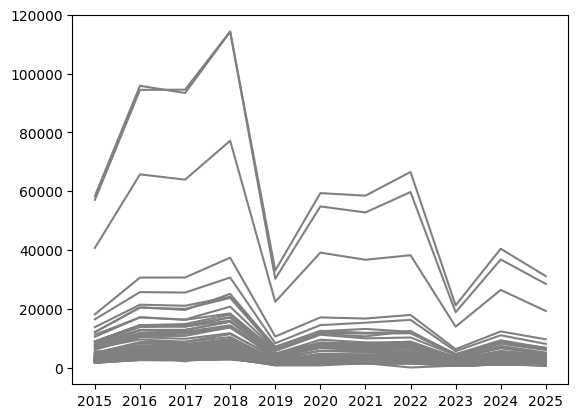

In [58]:
x = plot_this['year'].unique()
top_words = plot_this.groupby("word")["word_n"].sum().nlargest(100).index
df_top = plot_this[plot_this["word"].isin(top_words)]
for word in df_top['word'].unique():
    y = df_top['word_n'][df_top['word']==word]
    plt.plot(x, y, label=word, linestyle='-', color='grey')

plt.show()